<a href="https://colab.research.google.com/github/Zz-web700/hw/blob/main/PKU1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pandas numpy matplotlib seaborn jieba scikit-learn transformers torch
!pip install pypdf2 python-docx
!pip install wordcloud

import os
import json
import re
import pandas as pd
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import jieba
import jieba.posseg as pseg
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 设置随机种子
np.random.seed(42)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 25.0 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/jieba/__init__.py:44: SyntaxWarning: invalid escape sequence '\.'
  re_han_default = re.compile("([\u4E00-\u9FD5a-zA-Z0-9+#&\._%\-]+)", re.U)
/usr/local/lib/python3.12/dist-packages/jieba/__init__.py:46: SyntaxWarning: invalid escape sequence '\s'
  re_skip_default = re.compile("(\r\n|\s)", re.U)
/usr/local/lib/python3.12/dist-packages/jieba/finalseg/__init__.py:78: SyntaxWarning: invalid escape sequence '\.'
  re_skip = re.compile("([a-zA-Z0-9]+(?:\.\d+)?%?)")
/usr/local/lib/python3.12/dist-packages/jieba/posseg/__init__.py:16: SyntaxWarning: invalid escape sequence '\.'
  re_skip_detail = re.compile("([\.0-9]+|[a-zA-Z0-9]+)")
/usr/local/lib/python3.12/dist-packages/jieba/posseg/__init__.py:17: SyntaxWarning: invalid escape sequence '\.'
  re_han_internal = re.compile("([\u4E00-\u9FD5a-zA-Z0-9+#&\._]+)")
/usr/local/lib/python3.12/dist-packages/jieba/posseg/__init__.py:18: SyntaxWarning: invalid escape sequence '\s'
  re_skip_internal = re.compil

In [2]:
# ==================== 上传代码 ====================
def quick_upload_and_extract():
    """
    快速上传和解压
    """
    from google.colab import files
    import zipfile
    import os

    print("📤 请上传PKU-Corpus.zip压缩包:")
    uploaded = files.upload()

    # 查找zip文件
    zip_file = None
    for filename in uploaded.keys():
        if filename.endswith('.zip'):
            zip_file = filename
            break

    if not zip_file:
        print("❌ 未找到ZIP文件")
        return None

    print(f"✅ 已上传: {zip_file}")

    # 解压
    print(f"正在解压 {zip_file}...")
    with zipfile.ZipFile(zip_file, 'r') as zip_ref:
        zip_ref.extractall("articles")

    print("✅ 解压完成! 文件保存在 articles/ 文件夹")

    # 检查文件
    md_files = []
    for root, dirs, files in os.walk("articles"):
        for file in files:
            if file.endswith('.md'):
                md_files.append(os.path.join(root, file))

    print(f"找到 {len(md_files)} 个markdown文件")

    if md_files:
        print("📁 文件夹结构示例:")
        for i, file in enumerate(md_files[:3]):
            print(f"  {i+1}. {os.path.relpath(file, 'articles')}")

    return zip_file

# 运行
quick_upload_and_extract()

📤 请上传PKU-Corpus.zip压缩包:


Saving PKU-Corpus.zip to PKU-Corpus.zip
✅ 已上传: PKU-Corpus.zip
正在解压 PKU-Corpus.zip...
✅ 解压完成! 文件保存在 articles/ 文件夹
找到 1127 个markdown文件
📁 文件夹结构示例:
  1. 汇总统计.md
  2. 2025-11/2025-11-21_02_医学影像开始实现全国“漫游”.md
  3. 2025-11/2025-11-24_18_专家探讨加快保险机构数智化转型（财经短波）.md


'PKU-Corpus.zip'

数据加载模块

In [3]:
# ==================== 第3步：数据加载 ====================
def load_data():
    """加载现有文件结构的数据"""
    print("=== 数据加载 ===")

    # 检查articles文件夹是否存在
    if not os.path.exists("articles"):
        print("❌ 错误：未找到 'articles' 文件夹！")
        print("当前目录内容：")
        print(os.listdir('.'))
        return None, None

    # 统计文件夹结构
    print("📁 文件夹结构：")
    for root, dirs, files in os.walk("articles"):
        level = root.replace("articles", "").count(os.sep)
        indent = " " * 2 * level
        print(f"{indent}{os.path.basename(root)}/")
        subindent = " " * 2 * (level + 1)
        for file in files[:5]:  # 只显示前5个文件
            print(f"{subindent}{file}")
        if len(files) > 5:
            print(f"{subindent}... 还有{len(files)-5}个文件")

    # 加载所有markdown文章
    articles_df = load_articles_from_folders("articles")

    if articles_df is None or len(articles_df) == 0:
        print("❌ 没有加载到任何文章！")
        return None, None

    # 尝试加载标注数据（如果有）
    annotated_df = None
    json_files = [f for f in os.listdir('.') if f.endswith('.json')]
    if json_files:
        try:
            with open(json_files[0], 'r', encoding='utf-8') as f:
                annotated_data = json.load(f)
            annotated_df = pd.DataFrame(annotated_data)
            print(f"✅ 加载标注数据: {len(annotated_df)} 条")
        except:
            print("⚠️ 无法加载标注文件，将继续处理文章数据")

    print(f"\n✅ 数据加载完成!")
    print(f"   文章总数: {len(articles_df)} 篇")
    if annotated_df is not None:
        print(f"   标注数据: {len(annotated_df)} 条")

    return annotated_df, articles_df

def load_articles_from_folders(root_folder):
    """从文件夹结构加载文章"""
    all_articles = []
    all_files = []

    # 收集所有markdown文件
    for root, dirs, files in os.walk(root_folder):
        for file in files:
            if file.endswith(('.md', '.markdown', '.txt')):
                file_path = os.path.join(root, file)
                all_files.append(file_path)

    print(f"\n📂 找到 {len(all_files)} 个markdown文件")

    for file_path in tqdm(all_files, desc="加载文章"):
        try:
            with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
                content = f.read()

            if len(content) < 20:  # 跳过太短的文件
                continue

            # 提取基本信息
            filename = os.path.basename(file_path)

            # 从文件路径提取日期信息
            date_match = re.search(r'(\d{4}-\d{2}-\d{2})', file_path)
            if not date_match:
                # 尝试从文件名提取
                date_match = re.search(r'(\d{4}-\d{2}-\d{2})', filename)

            date = date_match.group(1) if date_match else ""

            # 提取月份文件夹
            month_folder = ""
            for part in file_path.split(os.sep):
                if re.match(r'\d{4}-\d{2}', part):
                    month_folder = part
                    break

            # 提取标题
            title = ""
            title_patterns = [
                r'^#\s*(.+)$',  # Markdown标题
                r'^标题[:：]\s*(.+)',  # 标题标签
                r'^(.*?)[\n\r]{2}'  # 第一段
            ]

            for pattern in title_patterns:
                match = re.search(pattern, content, re.MULTILINE)
                if match:
                    title = match.group(1).strip()[:100]
                    break

            if not title or len(title) < 2:
                title = filename.replace('.md', '').replace('.markdown', '').replace('.txt', '')[:100]

            # 提取正文
            lines = content.split('\n')
            body = ""
            for i, line in enumerate(lines):
                line = line.strip()
                if line and not line.startswith('#') and not line.startswith('标题') and len(line) > 10:
                    body = '\n'.join(lines[i:i+50])  # 取前50行
                    break

            if not body:
                body = content[:2000]  # 如果没找到正文，取前2000字符

            # 验证是否包含"北京大学"
            if "北京大学" in content or "北大" in content:
                all_articles.append({
                    'id': len(all_articles),
                    'filename': filename,
                    'filepath': file_path,
                    'month': month_folder,
                    'title': title[:150],
                    'date': date,
                    'content': body[:5000],  # 限制长度
                    'full_content': content[:10000]
                })

        except Exception as e:
            continue

    print(f"✅ 成功加载 {len(all_articles)} 篇有效文章")

    # 转换为DataFrame
    df = pd.DataFrame(all_articles)

    # 按日期排序
    if 'date' in df.columns and not df['date'].isna().all():
        try:
            df['date'] = pd.to_datetime(df['date'], errors='coerce')
            df = df.sort_values('date').reset_index(drop=True)
        except:
            pass

    return df

# 运行数据加载
annotated_df, articles_df = load_data()

# 显示基本信息
if articles_df is not None:
    print(f"\n📊 文章数据基本信息:")
    print(f"总文章数: {len(articles_df)}")
    if 'date' in articles_df.columns:
        valid_dates = articles_df['date'].notna()
        if valid_dates.any():
            print(f"时间范围: {articles_df[valid_dates]['date'].min()} 到 {articles_df[valid_dates]['date'].max()}")

    if 'month' in articles_df.columns:
        print(f"\n📅 月份分布:")
        month_counts = articles_df['month'].value_counts()
        for month, count in month_counts.head(12).items():
            print(f"  {month}: {count}篇")

    print(f"\n📝 前5篇文章标题:")
    for i, row in articles_df.head().iterrows():
        print(f"  {i+1}. {row['title']}")

=== 数据加载 ===
📁 文件夹结构：
articles/
  汇总统计.md
  2025-11/
    2025-11-21_02_医学影像开始实现全国“漫游”.md
    2025-11-24_18_专家探讨加快保险机构数智化转型（财经短波）.md
    2025-11-17_05_为中国1426亿棵树建“绿色账本”（中国道路中国梦·每一个人都是主角）.md
    2025-11-29_06_对大脑进行“彩色直播”（探一线）.md
    2025-11-15_03_全球南方现代化论坛将在北京举行.md
    ... 还有30个文件
  2023-12/
    2023-12-22_03_携手奔向下一个金色十年（2023·年终专稿）.md
    2023-12-03_03_促进地区可持续发展是新中合作的重要机遇（国际论坛）.md
    2023-12-19_18_传承友好精神，永固和平“金桥”.md
    2023-12-01_16_医疗人才“组团式”援疆成效显著（健康焦点）.md
    2023-12-05_15_土壤也会呼吸吗？（把自然讲给你听）.md
    ... 还有27个文件
  2024-12/
    2024-12-15_03_加强企业国际形象建设 讲好中国式现代化故事.md
    2024-12-08_07_河南郑州 产业向“新” 发展提“质”.md
    2024-12-30_18_因地制宜发展数字经济（创新故事）.md
    2024-12-01_04_努力为推进马克思主义中国化时代化作出更大贡献.md
    2024-12-16_08_关于第九届全国道德模范候选人的公示.md
    ... 还有23个文件
  2025-06/
    2025-06-17_18_我的文学跨越之旅.md
    2025-06-28_03_中国消费市场向世界展示开放姿态（国际论坛）.md
    2025-06-10_09_不断推动构建人类命运共同体（深入学习贯彻习近平新时代中国特色社会主义思想·访谈录）.md
    2025-06-16_19_新技术带来发展新优势（一周科技观察）.md
    2025-06-05_05_“跳出河南发展河南”（连线评论员）.md
    ... 还有15个文件
  2024-07/

加载文章: 100%|██████████| 1127/1127 [00:00<00:00, 9385.11it/s]

✅ 成功加载 1127 篇有效文章

✅ 数据加载完成!
   文章总数: 1127 篇

📊 文章数据基本信息:
总文章数: 1127
时间范围: 2023-01-03 00:00:00 到 2026-03-27 00:00:00

📅 月份分布:
  2023-05: 46篇
  2024-05: 42篇
  2023-11: 38篇
  2023-06: 38篇
  2024-04: 38篇
  2024-11: 37篇
  2023-07: 37篇
  2025-05: 37篇
  2025-04: 37篇
  2025-11: 35篇
  2025-07: 33篇
  2023-12: 32篇

📝 前5篇文章标题:
  1. 中国战略性新兴产业发展指数发布
  2. 抗病毒药物应在医生指导下使用
  3. “用团结的力量扫除疫情阴霾”（国际社会看中国优化疫情防控措施）
  4. 新版诊疗方案更科学、更有针对性
  5. 做好诊疗关口前移和重症患者救治（国务院联防联控机制发布会）


任务一、人物的抽取

In [4]:
!pip install aistudio-sdk==0.2.6

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 411.9/411.9 kB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.0/80.0 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 83.3 MB/s eta 0:00:00



⏳ 正在从 Hugging Face 下载 Qwen/Qwen2.5-1.5B-Instruct 模型 (约 3GB)...



config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

✅ 模型加载成功！目前运行在: cuda:0 (如果显示 cuda:0 说明 GPU 已成功接管！)

🚀 开始使用 Hugging Face 模型进行抽取（T4 GPU 满血加速中，预计几分钟完成）...

⏳ 正在处理前 200 篇文章...


提取进度: 100%|██████████| 200/200 [12:28<00:00,  3.74s/it]



🎯 任务1 结果分析报告 (Hugging Face 本地模型版)
✅ 共从语料中成功提取到 96 个人物出场记录。

🏆 高频人物排行榜 TOP 20:
 name            organization         position  count
  王贵强           北京大学第一医院感染疾病科               主任      3
   王博                    北京大学              副校长      3
  林毅夫           北京大学新结构经济学研究院               院长      2
   郝平                北京大学党委书记                       2
  赵扬玉             北京大学第三医院妇产科               主任      2
   于静                    北京大学 2009年哈尔滨大冬会首棒火炬手      1
  傅小强                    北京大学               专家      1
  刘博洋                    北京大学         90后天文摄影师      1
   丁宁               北京大学体育教研部            硕士研究生      1
  唐有祺           北京大学化学与分子工程学院               教授      1
  唐正东                    北京大学               专家      1
大江健三郎                    北京大学           北京大学教授      1
   姚洋                    北京大学                       1
  孙于谦                北京大学人民医院            副主任医师      1
  孙庆伟            北京大学党委常委、副校长                       1
  孙永昌       北京大学第三医院呼吸与危重症医学科               主任      1
  孙

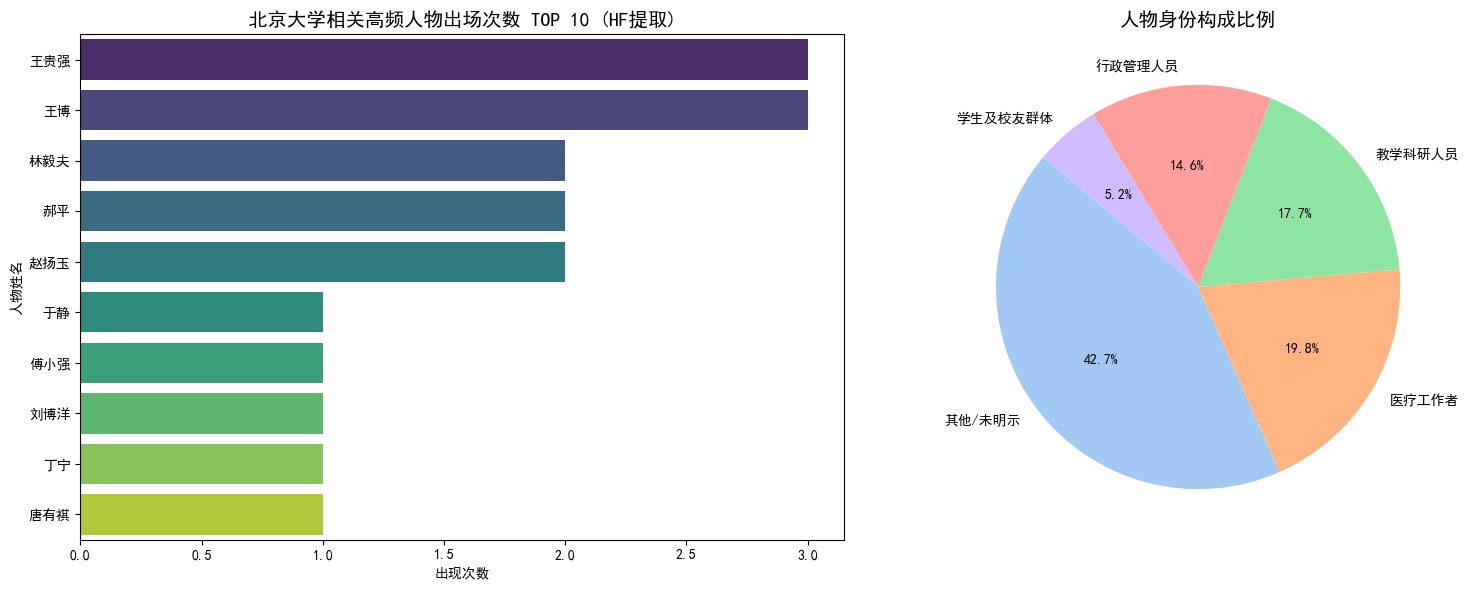


💾 任务完成！本地开源大模型版文件已保存：
1. 'task1_hf_full_results.csv' (全量结果)
2. 'task1_hf_manual_check.csv' (✅ 抽检表)


In [5]:
import os
import glob
import json
import re
import torch
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoModelForCausalLM, AutoTokenizer

# 修复 Colab 图表中文乱码问题
!wget -q -O /usr/share/fonts/truetype/liberation/simhei.ttf https://github.com/StellarCN/scp_zh/raw/master/fonts/SimHei.ttf
import matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/liberation/simhei.ttf')
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# ==================== 2. 加载 Hugging Face 开源小模型 ====================
# 使用 Qwen2.5-1.5B-Instruct
model_name = "Qwen/Qwen2.5-1.5B-Instruct"

print(f"\n⏳ 正在从 Hugging Face 下载 {model_name} 模型 (约 3GB)...\n")
tokenizer = AutoTokenizer.from_pretrained(model_name)

# 🚀 核心修复：开启半精度 + 自动映射到 T4 GPU
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16, # 极度关键：节省一半显存，推理速度翻倍！
    device_map="auto"          # 极度关键：自动识别并满血调用 T4 GPU
)
print("✅ 模型加载成功！目前运行在:", model.device, "(如果显示 cuda:0 说明 GPU 已成功接管！)")


# ==================== 4. 强化版抽取函数 ====================
def extract_pku_persons_hf(text):
    """使用本地 Hugging Face 模型进行抽取"""
    truncated_text = text[:1500]

    prompt = f"""请阅读以下新闻，提取其中提及的【隶属于北京大学】（包含北大、北京大学XX医院、北大XX学院等附属机构）的具体人物信息。
    ⚠️ 严格警告：
    1. 必须是【北京大学】的人！绝对不要提取其他高校、政府机关或企业的人员！
    2. 只输出一个合法的 JSON 数组，包含 name (姓名), organization (单位), position (职务) 三个字段。
    3. 如果没有北大相关人物，必须严格输出 []。

    新闻文本：
    {truncated_text}
    """

    messages = [
        {"role": "system", "content": "你是一个严谨的信息抽取专家，必须严格以JSON数组格式输出结果，绝不包含任何多余字符。"},
        {"role": "user", "content": prompt}
    ]

    text_input = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    # 确保输入数据也丢给 GPU
    model_inputs = tokenizer([text_input], return_tensors="pt").to(model.device)

    try:
        generated_ids = model.generate(
            **model_inputs,
            max_new_tokens=256,   # 降低生成长度上限，提速
            do_sample=False       # 关闭随机性，保证输出格式稳定
        )

        generated_ids = [
            output_ids[len(input_ids):] for input_ids, output_ids in zip(model_inputs.input_ids, generated_ids)
        ]
        response = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]

        json_str = response.strip()
        json_str = re.sub(r'^```json\s*', '', json_str)
        json_str = re.sub(r'\s*```$', '', json_str)

        return json.loads(json_str)

    except json.JSONDecodeError:
        # 模型偶尔没按 JSON 输出，打印出来看看它在发什么疯
        # print(f"解析失败输出: {response}")
        return []
    except Exception as e:
        return []


# ==================== 5. 批量处理与强制过滤 ====================
print("\n🚀 开始使用 Hugging Face 模型进行抽取（T4 GPU 满血加速中，预计几分钟完成）...")
all_extracted_data = []
results_for_df = []

# 确保 articles_df 存在且非空
if 'articles_df' not in locals() or articles_df.empty:
    print("⚠️ 错误: 'articles_df' DataFrame 未加载或为空。请检查之前的步骤是否成功加载了数据。")
else:
    # 限制处理的文章数量以控制运行时间，您可以在测试通过后解除注释或调整数量
    articles_to_process = articles_df.head(200)
    print(f"\n⏳ 正在处理前 {len(articles_to_process)} 篇文章...")

    for index, article_row in tqdm(articles_to_process.iterrows(), total=len(articles_to_process), desc="提取进度"):
        persons = extract_pku_persons_hf(article_row['content'])

        if not isinstance(persons, list):
            persons = []

        valid_persons = []

        for p in persons:
            if not isinstance(p, dict): continue

            org = str(p.get("organization", "未知")).strip()
            name = str(p.get("name", "未知")).strip()
            pos = str(p.get("position", "未知")).strip()

            # 单位没有北大，不要！
            if "北大" not in org and "北京大学" not in org:
                continue

            # 名字太长或包含机构词，不要！
            if len(name) > 5 or any(kw in name for kw in ["大学", "医院", "学院", "中心", "系", "团队", "师生", "代表"]):
                continue

            # 排除国家领导人视察造成的误提！
            national_leaders = ["习近平", "李克强", "李强", "赵乐际", "王沪宁", "蔡奇", "丁薛祥", "李希"]
            if name in national_leaders or any(title in pos for title in ["总书记", "国家主席", "总理", "委员长"]):
                continue

            valid_persons.append(p)
            all_extracted_data.append({
                "name": name,
                "organization": org,
                "position": pos,
                "source_article": article_row['filename']
            })

        results_for_df.append({
            "filename": article_row['filename'],
            "extracted_persons": json.dumps(valid_persons, ensure_ascii=False)
        })

df_persons = pd.DataFrame(all_extracted_data)

# ==================== 6. 统计汇总与可视化 ====================
print("\n" + "="*50)
print("🎯 任务1 结果分析报告 (Hugging Face 本地模型版)")
print("="*50)

if not df_persons.empty:
    print(f"✅ 共从语料中成功提取到 {len(df_persons)} 个人物出场记录。\n")

    # 排名
    top_persons = df_persons.groupby(['name', 'organization', 'position']).size().reset_index(name='count')
    top_persons = top_persons.sort_values(by='count', ascending=False).head(20)
    print("🏆 高频人物排行榜 TOP 20:")
    print(top_persons.to_string(index=False))

    # 身份归类
    def categorize_role(pos):
        pos = str(pos)
        if any(kw in pos for kw in ['院士', '教授', '研究员', '博导', '讲师']): return "教学科研人员"
        if any(kw in pos for kw in ['医生', '医师', '主任', '护士']): return "医疗工作者"
        if any(kw in pos for kw in ['书记', '校长', '院长', '处长']): return "行政管理人员"
        if any(kw in pos for kw in ['学生', '硕士', '博士', '青年']): return "学生及校友群体"
        return "其他/未明示"

    df_persons['role_category'] = df_persons['position'].apply(categorize_role)
    role_counts = df_persons['role_category'].value_counts()

    print("\n📈 身份构成分析:")
    for role, count in role_counts.items():
        print(f"  - {role}: {count} 人次 ({count/len(df_persons):.1%})")

    # 可视化图表
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    sns.barplot(data=top_persons.head(10), y='name', x='count', ax=axes[0], palette='viridis')
    axes[0].set_title('北京大学相关高频人物出场次数 TOP 10 (HF提取)', fontsize=14)
    axes[0].set_xlabel('出现次数')
    axes[0].set_ylabel('人物姓名')

    axes[1].pie(role_counts, labels=role_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
    axes[1].set_title('人物身份构成比例', fontsize=14)
    plt.tight_layout()
    plt.show()

else:
    print("⚠️ 未能提取到任何符合条件的人物信息。")

# ==================== 7. 导出抽检样本 ====================
df_results = pd.DataFrame(results_for_df)
sample_size = min(20, len(df_results))
sample_20 = df_results.sample(n=sample_size, random_state=42)

df_results.to_csv("task1_hf_full_results.csv", index=False, encoding='utf-8-sig')
sample_20.to_csv("task1_hf_manual_check.csv", index=False, encoding='utf-8-sig')

print("\n💾 任务完成！本地开源大模型版文件已保存：")
print("1. 'task1_hf_full_results.csv' (全量结果)")
print("2. 'task1_hf_manual_check.csv' (✅ 抽检表)")

任务二、北大角色分类

开始执行任务2: 北大角色分类...
任务2: 北大角色分类
分析文章数: 200 篇


角色分类: 100%|██████████| 200/200 [00:00<00:00, 19573.03it/s]


📊 角色分类结果:
  仅背景出现: 130篇 (65.0%)
  提及北大: 33篇 (16.5%)
  未出现: 29篇 (14.5%)
  主要报道北大: 8篇 (4.0%)

📈 生成可视化图表...


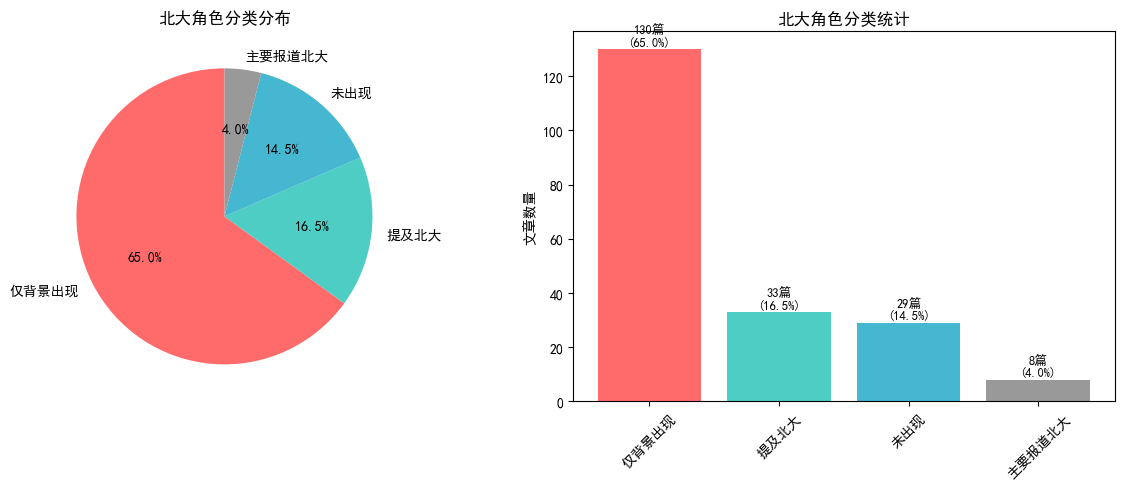


✅ 任务2完成!


In [6]:
# ==================== 任务2：北大角色分类 ====================
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
def classify_pku_role(text, title):
    """分类北大在文章中的角色"""
    if not isinstance(text, str):
        text = ""
    if not isinstance(title, str):
        title = ""

    full_text = str(title) + ' ' + str(text)
    full_text = full_text.replace("北大", "北京大学")

    pku_count = full_text.count("北京大学")
    in_title = "北京大学" in str(title)

    if in_title or pku_count >= 5:
        return "主要报道北大", pku_count
    elif pku_count >= 2:
        return "提及北大", pku_count
    elif pku_count == 1:
        return "仅背景出现", pku_count
    else:
        return "未出现", pku_count

def task2_analysis(articles_df, sample_size=200):
    """任务2主函数"""
    print("="*60)
    print("任务2: 北大角色分类")
    print("="*60)

    if sample_size and sample_size < len(articles_df):
        df = articles_df.head(sample_size)
    else:
        df = articles_df

    print(f"分析文章数: {len(df)} 篇")

    # 分类
    results = []

    for idx, row in tqdm(df.iterrows(), total=len(df), desc="角色分类"):
        role, count = classify_pku_role(row.get('content', ''), row.get('title', ''))

        results.append({
            'article_id': idx,
            'title': row.get('title', ''),
            'date': row.get('date', ''),
            'role': role,
            'pku_count': count
        })

    results_df = pd.DataFrame(results)

    # 统计分析
    role_counts = results_df['role'].value_counts()
    total = len(results_df)

    print(f"\n📊 角色分类结果:")
    for role, count in role_counts.items():
        percentage = count / total * 100
        print(f"  {role}: {count}篇 ({percentage:.1f}%)")

    # 可视化
    visualize_task2_results(results_df, role_counts)

    return results_df

def visualize_task2_results(results_df, role_counts):
    """可视化任务2结果"""
    print("\n📈 生成可视化图表...")

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # 1. 饼图
    colors = ['#ff6b6b', '#4ecdc4', '#45b7d1', '#999999']
    axes[0].pie(role_counts.values, labels=role_counts.index, autopct='%1.1f%%',
                colors=colors[:len(role_counts)], startangle=90)
    axes[0].set_title('北大角色分类分布', fontsize=12, fontweight='bold')

    # 2. 柱状图
    bars = axes[1].bar(role_counts.index, role_counts.values,
                       color=colors[:len(role_counts)])
    axes[1].set_title('北大角色分类统计', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('文章数量')
    axes[1].tick_params(axis='x', rotation=45)

    # 在柱子上添加数字
    total = len(results_df)
    for bar, count in zip(bars, role_counts.values):
        percentage = count / total * 100
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f'{count}篇\n({percentage:.1f}%)',
                    ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()

# 运行任务2
if articles_df is not None:
    print("开始执行任务2: 北大角色分类...")
    role_results = task2_analysis(articles_df, sample_size=200)
    print("\n✅ 任务2完成!")
else:
    print("❌ 无法执行任务2：文章数据未加载")

任务三、情感分析

开始执行任务3: 情感分析...
任务3: 情感分析
分析文章数: 200 篇


情感分析: 100%|██████████| 200/200 [00:00<00:00, 8099.22it/s]


📊 情感分析结果:
  正面: 181篇 (90.5%)
  中性: 14篇 (7.0%)
  负面: 5篇 (2.5%)
  平均置信度: 0.77

📈 生成可视化图表...


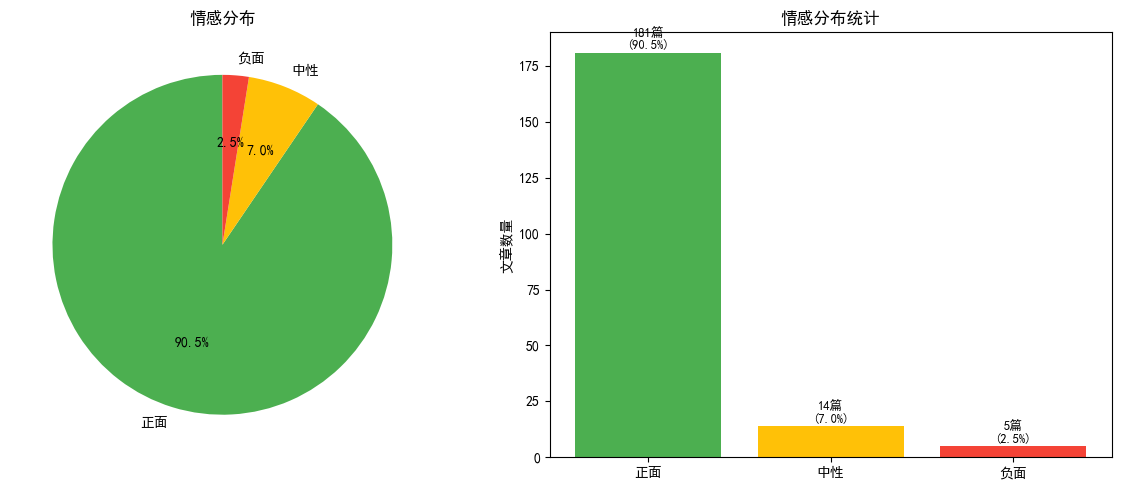


✅ 任务3完成!


In [7]:
# ==================== 任务3：情感分析 ====================
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
def analyze_sentiment(text):
    """简单情感分析"""
    if not isinstance(text, str):
        return "中性", 0.5, 0

    text = text[:2000]  # 限制长度

    # 正面词汇
    positive_words = [
        '成就', '成功', '优秀', '杰出', '突破', '创新', '领先', '一流', '卓越',
        '贡献', '表彰', '获奖', '先进', '发展', '进步', '提升', '改善', '积极',
        '肯定', '赞扬', '表扬', '鼓励', '支持', '合作', '成果', '发表', '研究',
        '学术', '科研', '教育', '培养', '人才', '国际', '领先', '顶尖', '著名'
    ]

    # 负面词汇
    negative_words = [
        '问题', '困难', '挑战', '不足', '批评', '争议', '事故', '错误', '失败',
        '质疑', '担忧', '忧虑', '负面', '消极', '否定', '反对', '抗议', '冲突',
        '矛盾', '纠纷', '灾难', '损失', '损害', '伤害', '危险', '风险', '弊端'
    ]

    pos_count = sum(1 for word in positive_words if word in text)
    neg_count = sum(1 for word in negative_words if word in text)

    if pos_count > neg_count + 1:
        confidence = min(0.5 + (pos_count - neg_count) / 20, 0.95)
        return "正面", confidence, pos_count - neg_count
    elif neg_count > pos_count + 1:
        confidence = min(0.5 + (neg_count - pos_count) / 20, 0.95)
        return "负面", confidence, pos_count - neg_count
    else:
        return "中性", 0.5, pos_count - neg_count

def task3_analysis(articles_df, sample_size=200):
    """任务3主函数"""
    print("="*60)
    print("任务3: 情感分析")
    print("="*60)

    if sample_size and sample_size < len(articles_df):
        df = articles_df.head(sample_size)
    else:
        df = articles_df

    print(f"分析文章数: {len(df)} 篇")

    # 情感分析
    results = []

    for idx, row in tqdm(df.iterrows(), total=len(df), desc="情感分析"):
        sentiment, confidence, score = analyze_sentiment(
            str(row.get('title', '')) + ' ' + str(row.get('content', ''))
        )

        results.append({
            'article_id': idx,
            'title': row.get('title', ''),
            'sentiment': sentiment,
            'confidence': confidence,
            'score': score
        })

    results_df = pd.DataFrame(results)

    # 统计分析
    sentiment_counts = results_df['sentiment'].value_counts()
    total = len(results_df)

    print(f"\n📊 情感分析结果:")
    for sentiment, count in sentiment_counts.items():
        percentage = count / total * 100
        print(f"  {sentiment}: {count}篇 ({percentage:.1f}%)")

    # 平均置信度
    avg_confidence = results_df['confidence'].mean()
    print(f"  平均置信度: {avg_confidence:.2f}")

    # 可视化
    visualize_task3_results(results_df, sentiment_counts)

    return results_df

def visualize_task3_results(results_df, sentiment_counts):
    """可视化任务3结果"""
    print("\n📈 生成可视化图表...")

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # 1. 饼图
    colors = {'正面': '#4CAF50', '中性': '#FFC107', '负面': '#F44336'}
    sentiment_colors = [colors.get(s, '#999999') for s in sentiment_counts.index]

    axes[0].pie(sentiment_counts.values, labels=sentiment_counts.index, autopct='%1.1f%%',
                colors=sentiment_colors, startangle=90)
    axes[0].set_title('情感分布', fontsize=12, fontweight='bold')

    # 2. 柱状图
    bars = axes[1].bar(sentiment_counts.index, sentiment_counts.values, color=sentiment_colors)
    axes[1].set_title('情感分布统计', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('文章数量')

    # 在柱子上添加数字
    total = len(results_df)
    for bar, count in zip(bars, sentiment_counts.values):
        percentage = count / total * 100
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f'{count}篇\n({percentage:.1f}%)',
                    ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()

# 运行任务3
if articles_df is not None:
    print("开始执行任务3: 情感分析...")
    sentiment_results = task3_analysis(articles_df, sample_size=200)
    print("\n✅ 任务3完成!")
else:
    print("❌ 无法执行任务3：文章数据未加载")

任务四、无监督聚类

开始执行全量文章分析...
任务4: 无监督聚类 (K-Means + TF-IDF)
分析文章数: 1127 篇
正在进行中文分词处理 (这可能需要十几秒)...


分词进度:   0%|          | 0/1127 [00:00<?, ?it/s]Building prefix dict from the default dictionary ...
DEBUG:jieba:Building prefix dict from the default dictionary ...
Dumping model to file cache /tmp/jieba.cache
DEBUG:jieba:Dumping model to file cache /tmp/jieba.cache
Loading model cost 0.918 seconds.
DEBUG:jieba:Loading model cost 0.918 seconds.
Prefix dict has been built successfully.
DEBUG:jieba:Prefix dict has been built successfully.
分词进度: 100%|██████████| 1127/1127 [00:09<00:00, 121.41it/s]


进行 TF-IDF 向量化...
执行 K-means 聚类 (聚类数量 K=5)...

📊 聚类分析结果 (共 5 个簇):

🔹 簇 0 | 自动归纳主题: 【教育-习近平-社会主义】
   文章数量: 161 篇 (14.3%)
   核心关键词: 教育, 习近平, 社会主义, 现代化, 学习
   代表性文章 (距离中心点最近):
    1. 发挥高等教育龙头引领作用（深入学习贯彻习近平新时代中国特色社会主义思想）
    2. 向教育强国稳步前行
    3. 加快建设中国特色世界一流大学（学思想 强党性 重实践 建新功）

🔹 簇 1 | 自动归纳主题: 【青年-世界-合作】
   文章数量: 369 篇 (32.7%)
   核心关键词: 青年, 世界, 合作, 主席, 国际
   代表性文章 (距离中心点最近):
    1. 为全球发展贡献智慧和力量
    2. 全国台联第三十一届台胞青年冬令营在京开营
    3. 铭记历史，共同珍视岁月凝结的友谊纽带

🔹 簇 2 | 自动归纳主题: 【文化-艺术-传统】
   文章数量: 131 篇 (11.6%)
   核心关键词: 文化, 艺术, 传统, 历史, 中华
   代表性文章 (距离中心点最近):
    1. 文化事业和文化产业高质量发展一年间（新时代画卷）
    2. 担负新的文化使命（人民观点）
    3. 让少数民族文化特色在利用中更加鲜亮

🔹 簇 3 | 自动归纳主题: 【考古-遗址-发掘】
   文章数量: 49 篇 (4.3%)
   核心关键词: 考古, 遗址, 发掘, 发现, 文化
   代表性文章 (距离中心点最近):
    1. 揭示古老文化的生动面貌（考古中国）
    2. 将考古成果转化为考古大学堂
    3. 全国十大考古新发现揭晓（推进文化自信自强）

🔹 簇 4 | 自动归纳主题: 【科技-创新-健康】
   文章数量: 417 篇 (37.0%)
   核心关键词: 科技, 创新, 健康, 企业, 服务
   代表性文章 (距离中心点最近):
    1. 财经短波
    2. 加快医药创新发展 更好保障人民健康
    3. 绵阳 因科技而兴 因创新而盛

📈 生成可视化图表...
进行 PCA 降维...


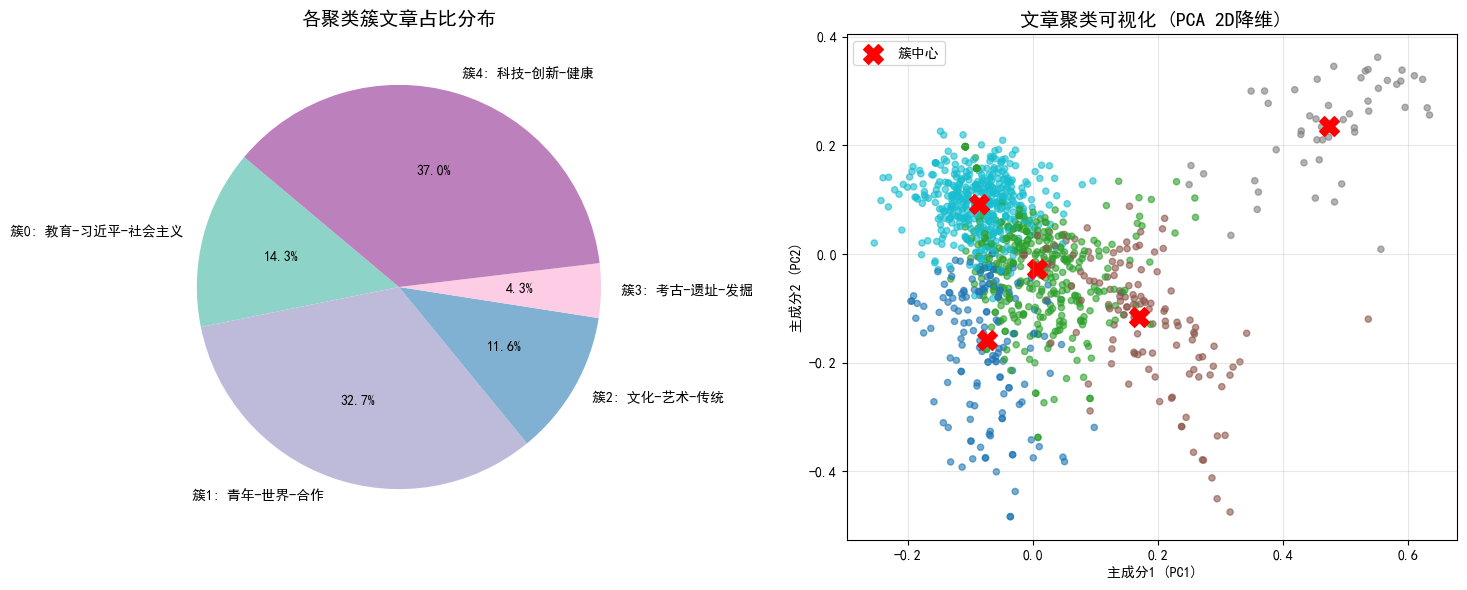


✅ 任务4完成!


In [8]:
import numpy as np
import pandas as pd
import jieba
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import euclidean_distances
from tqdm import tqdm

plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 常见中文停用词表（简易版，涵盖大部分无意义词汇）
STOP_WORDS = set(['的', '了', '在', '是', '我', '有', '和', '就', '不', '人', '都', '一', '一个', '上',
                  '也', '很', '到', '说', '要', '去', '你', '会', '着', '没有', '看', '好', '自己', '这',
                  '我们', '北京大学', '北大', '大学', '记者', '报道', '新华社', '日电', '本报', '月', '日',
                  '发展', '工作', '建设', '中国', '国家'])

def preprocess_chinese_text(text):
    """使用 jieba 进行中文分词并过滤停用词"""
    if not isinstance(text, str):
        return ""
    # 分词
    words = jieba.lcut(text)
    # 过滤停用词、标点符号，保留长度大于1的词
    valid_words = [w for w in words if w not in STOP_WORDS and len(w) > 1 and not w.isnumeric()]
    return " ".join(valid_words)

def task4_analysis(articles_df, n_clusters=5):
    """任务4主函数：改进版无监督聚类"""
    print("="*60)
    print("任务4: 无监督聚类 (K-Means + TF-IDF)")
    print("="*60)

    # 跑全量数据
    df = articles_df.copy()
    print(f"分析文章数: {len(df)} 篇")

    # 1. 准备文本与分词处理
    print("正在进行中文分词处理 (这可能需要十几秒)...")
    tqdm.pandas(desc="分词进度")
    # 将标题和部分正文结合，并进行分词
    texts = df.progress_apply(lambda row: preprocess_chinese_text(f"{row.get('title', '')} {row.get('content', '')[:1000]}"), axis=1).tolist()

    # 2. TF-IDF向量化
    print("进行 TF-IDF 向量化...")
    vectorizer = TfidfVectorizer(
        max_features=1000, # 扩大特征维度以捕获更多语义
        token_pattern=r"(?u)\b\w+\b" # 适配中文分词后的空格
    )
    X = vectorizer.fit_transform(texts)

    # 3. 执行聚类
    print(f"执行 K-means 聚类 (聚类数量 K={n_clusters})...")
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(X)
    df['cluster'] = clusters

    # 4. 深度分析每个簇 (提取真实代表性特征)
    feature_names = vectorizer.get_feature_names_out()
    cluster_info = []

    for i in range(n_clusters):
        cluster_indices = np.where(clusters == i)[0]
        cluster_X = X[cluster_indices]

        # 获取簇中心
        center = kmeans.cluster_centers_[i]

        # 获取 Top 5 关键词作为该簇的无监督主题命名
        top_indices = center.argsort()[-5:][::-1]
        keywords = [feature_names[idx] for idx in top_indices]

        # 严格遵守“无预定义标签”，直接使用前3个核心关键词拼接作为主题名
        theme_name = "-".join(keywords[:3])

        # 寻找真正的“代表性文章”：计算该簇中所有文章到簇中心的欧式距离
        distances = euclidean_distances(cluster_X, center.reshape(1, -1)).flatten()
        # 找到距离最近的 3 篇文章的本地索引
        closest_local_indices = distances.argsort()[:3]
        # 映射回原始 DataFrame 的数据
        sample_titles = df.iloc[cluster_indices[closest_local_indices]]['title'].tolist()

        cluster_info.append({
            'cluster_id': i,
            'size': len(cluster_indices),
            'theme': theme_name,
            'keywords': keywords,
            'sample_titles': sample_titles
        })

    # 5. 打印结果
    print(f"\n📊 聚类分析结果 (共 {n_clusters} 个簇):")
    for info in cluster_info:
        print(f"\n🔹 簇 {info['cluster_id']} | 自动归纳主题: 【{info['theme']}】")
        print(f"   文章数量: {info['size']} 篇 ({info['size']/len(df):.1%})")
        print(f"   核心关键词: {', '.join(info['keywords'])}")
        print(f"   代表性文章 (距离中心点最近):")
        for j, title in enumerate(info['sample_titles']):
            print(f"    {j+1}. {title[:50]}")

    # 6. 可视化
    visualize_task4_results(clusters, cluster_info, X, kmeans)

    return clusters, cluster_info

def visualize_task4_results(clusters, cluster_info, X, kmeans):
    """可视化任务4结果"""
    print("\n📈 生成可视化图表...")

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # 1. 簇大小分布 (饼图，比柱状图更能直观展示比例)
    sizes = [info['size'] for info in cluster_info]
    themes = [f"簇{info['cluster_id']}: {info['theme']}" for info in cluster_info]

    colors = plt.cm.Set3(np.arange(len(cluster_info))/len(cluster_info))
    axes[0].pie(sizes, labels=themes, autopct='%1.1f%%', startangle=140, colors=colors)
    axes[0].set_title('各聚类簇文章占比分布', fontsize=14, fontweight='bold')

    # 2. PCA降维可视化
    print("进行 PCA 降维...")
    pca = PCA(n_components=2, random_state=42)
    X_2d = pca.fit_transform(X.toarray())

    scatter = axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c=clusters, cmap='tab10', alpha=0.6, s=20)

    # 标出聚类中心
    centers_2d = pca.transform(kmeans.cluster_centers_)
    axes[1].scatter(centers_2d[:, 0], centers_2d[:, 1], c='red', marker='X', s=200, label='簇中心')

    axes[1].set_title('文章聚类可视化 (PCA 2D降维)', fontsize=14, fontweight='bold')
    axes[1].set_xlabel(f'主成分1 (PC1)')
    axes[1].set_ylabel(f'主成分2 (PC2)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# 运行任务4
if articles_df is not None:
    print("开始执行全量文章分析...")
    # 可以通过 n_clusters 调整聚类数量
    clusters, cluster_info = task4_analysis(articles_df, n_clusters=5)
    print("\n✅ 任务4完成!")